
# RPS MobileNetV2 + Knowledge Distillation + QAT + INT8 TFLite

**TensorFlow-only / IMG_SIZE=64**

Dataset structure:

```text
RPS_Dataset/
├── 0  -> scissors
├── 1  -> rock
└── 2  -> paper
```

This notebook runs the full pipeline:

1. Load RPS dataset
2. Train ResNet50 teacher
3. Train MobileNetV2 student using Knowledge Distillation
4. Apply QAT with TensorFlow Model Optimization
5. Export INT8 TFLite
6. Compare Teacher / KD Student / QAT / TFLite accuracy and model size


In [ ]:

# =========================================================
# 0. Install packages
# =========================================================
# tf-keras + TF_USE_LEGACY_KERAS is included to improve compatibility
# between TensorFlow Model Optimization Toolkit and recent Colab runtimes.

!pip install -q tensorflow-model-optimization tf-keras opencv-python-headless scikit-learn pandas seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 3.3 MB/s eta 0:00:00


In [ ]:

# =========================================================
# 1. Imports and global settings
# =========================================================
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import glob
import time
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_model_optimization as tfmot

try:
    from tensorflow_model_optimization.python.core.keras.compat import keras
except Exception:
    from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

IMG_SIZE = 64
NUM_CLASSES = 3
BATCH_SIZE = 32
TEACHER_EPOCHS = 5
KD_EPOCHS = 5
QAT_EPOCHS = 3

CLASS_ID_TO_NAME = {
    0: "scissors",
    1: "rock",
    2: "paper",
}

CLASS_NAMES = [CLASS_ID_TO_NAME[i] for i in range(NUM_CLASSES)]

np.random.seed(42)
tf.random.set_seed(42)


TensorFlow Version: 2.20.0
NumPy Version: 2.0.2


## 2. Dataset clone and path setup

In [ ]:

# =========================================================
# 2. Clone repository and locate RPS_Dataset
# =========================================================
REPO_URL = "https://github.com/taegeonmin/RP2-RPS-QAT-Lab.git"
REPO_DIR = Path("/content/RP2-RPS-QAT-Lab")

if not REPO_DIR.exists():
    print("Cloning repository...")
    !git clone --depth 1 {REPO_URL} {str(REPO_DIR)}
else:
    print("Repository already exists:", REPO_DIR)

DATASET_DIR = REPO_DIR / "RPS_Dataset"

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"RPS_Dataset not found: {DATASET_DIR}")

print("Dataset path:", DATASET_DIR)
print("Class folders:", sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()]))


Cloning repository...
Cloning into '/content/RP2-RPS-QAT-Lab'...
remote: Enumerating objects: 2732, done.
remote: Counting objects: 100% (2732/2732), done.
remote: Compressing objects: 100% (2732/2732), done.
remote: Total 2732 (delta 2), reused 2726 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2732/2732), 368.02 MiB | 14.76 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (2725/2725), done.
Dataset path: /content/RP2-RPS-QAT-Lab/RPS_Dataset
Class folders: ['0', '1', '2']


## 3. Load dataset

Images are loaded as RGB, resized to 64×64, and kept in the **0~255 float32 range**. Preprocessing layers inside the models handle normalization.

In [ ]:

# =========================================================
# 3. Load images from RPS_Dataset/0,1,2
# =========================================================
images = []
labels = []

for class_id in range(NUM_CLASSES):
    class_dir = DATASET_DIR / str(class_id)

    if not class_dir.exists():
        raise FileNotFoundError(f"Class folder not found: {class_dir}")

    files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.JPG", "*.JPEG", "*.PNG", "*.BMP"]:
        files.extend(glob.glob(str(class_dir / ext)))

    print(f"Class {class_id} ({CLASS_ID_TO_NAME[class_id]}): {len(files)} images")

    for img_path in files:
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img.astype(np.float32))  # keep 0~255
        labels.append(class_id)

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int64)

print("images:", images.shape, images.dtype, "min/max:", images.min(), images.max())
print("labels:", labels.shape, labels.dtype)

if len(images) == 0:
    raise RuntimeError("No images were loaded. Check DATASET_DIR and class folders.")


Class 0 (scissors): 903 images
Class 1 (rock): 907 images
Class 2 (paper): 907 images
images: (2717, 64, 64, 3) float32 min/max: 0.0 255.0
labels: (2717,) int64


In [ ]:

# =========================================================
# 4. Train/Test split
# =========================================================
train_data, test_data, train_labels, test_labels = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

print("train_data:", train_data.shape)
print("test_data :", test_data.shape)
print("train_labels:", train_labels.shape)
print("test_labels :", test_labels.shape)


train_data: (2173, 64, 64, 3)
test_data : (544, 64, 64, 3)
train_labels: (2173,)
test_labels : (544,)


In [ ]:

# =========================================================
# 5. Data augmentation generator
# =========================================================
img_gen_train = keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.5, 1.2),
    zoom_range=0.2,
)

train_gen = img_gen_train.flow(
    train_data,
    train_labels,
    batch_size=BATCH_SIZE,
    seed=42,
)

steps_per_epoch = max(1, len(train_data) // BATCH_SIZE)
print("steps_per_epoch:", steps_per_epoch)


steps_per_epoch: 67


## 4. Build and train Teacher: ResNet50

In [ ]:

# =========================================================
# 6. Teacher model: ResNet50
# =========================================================
def build_teacher_resnet50():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_rgb_0_255")

    # ResNet preprocess_input expects 0~255 RGB images.
    x = keras.applications.resnet.preprocess_input(inputs)

    base_model = keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_tensor=x,
    )

    # Freeze BatchNorm layers for transfer learning stability.
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="teacher_output")(x)

    model = keras.Model(inputs, outputs, name="Teacher_ResNet50")
    return model

teacher_model = build_teacher_resnet50()

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_model.summary()


94765736/94765736 [==============================] - 1s 0us/step
Model: "Teacher_ResNet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_rgb_0_255 (InputLaye  [(None, 64, 64, 3)]          0         []                            
 r)                                                                                               
                                                                                                  
 tf.__operators__.getitem (  (None, 64, 64, 3)            0         ['input_rgb_0_255[0][0]']     
 SlicingOpLambda)                                                                                 
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.__operators__.getitem[0][
 )                

In [ ]:

# =========================================================
# 7. Train Teacher
# =========================================================
teacher_history = teacher_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=TEACHER_EPOCHS,
    validation_data=(test_data, test_labels),
)

teacher_model.save("teacher_resnet50.h5", include_optimizer=False)
print("Saved: teacher_resnet50.h5")


Epoch 1/5
67/67 [==============================] - 353s 5s/step - loss: 0.6541 - accuracy: 0.7361 - val_loss: 0.1631 - val_accuracy: 0.9430
Epoch 2/5
67/67 [==============================] - 343s 5s/step - loss: 0.2086 - accuracy: 0.9267 - val_loss: 0.0745 - val_accuracy: 0.9798
Epoch 3/5
67/67 [==============================] - 327s 5s/step - loss: 0.1064 - accuracy: 0.9598 - val_loss: 0.0489 - val_accuracy: 0.9908
Epoch 4/5
67/67 [==============================] - 328s 5s/step - loss: 0.0718 - accuracy: 0.9766 - val_loss: 0.0324 - val_accuracy: 0.9890
Epoch 5/5
67/67 [==============================] - 332s 5s/step - loss: 0.0627 - accuracy: 0.9771 - val_loss: 0.0328 - val_accuracy: 0.9926


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved: teacher_resnet50.h5


## 5. Build Student: MobileNetV2

In [ ]:

# =========================================================
# 8. Student model: MobileNetV2
# =========================================================
def build_student_mobilenetv2():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_rgb_0_255")

    # MobileNetV2 expects [-1, 1]. Equivalent to mobilenet_v2.preprocess_input.
    x = keras.layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mobilenet_preprocess")(inputs)

    base_model = keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_tensor=x,
        alpha=1.0,
    )

    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="student_output")(x)

    model = keras.Model(inputs, outputs, name="Student_MobileNetV2")
    return model

student_model = build_student_mobilenetv2()
student_model.summary()


9406464/9406464 [==============================] - 0s 0us/step
Model: "Student_MobileNetV2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_rgb_0_255 (InputLaye  [(None, 64, 64, 3)]          0         []                            
 r)                                                                                               
                                                                                                  
 mobilenet_preprocess (Resc  (None, 64, 64, 3)            0         ['input_rgb_0_255[0][0]']     
 aling)                                                                                           
                                                                                                  
 Conv1 (Conv2D)              (None, 32, 32, 32)           864       ['mobilenet_preprocess[0][0]']
                 

## 6. Knowledge Distillation

In [ ]:

# =========================================================
# 9. Distiller class
# =========================================================
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.student = student
        self.teacher = teacher

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.5,
        temperature=3.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def call(self, inputs, training=False):
        return self.student(inputs, training=training)

    def train_step(self, data):
        x, y = data

        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)

            loss = (1.0 - self.alpha) * student_loss + self.alpha * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
            "total_loss": loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


In [ ]:

# =========================================================
# 10. Train Student with Knowledge Distillation
# =========================================================
distiller = Distiller(student=student_model, teacher=teacher_model)

distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.5,
    temperature=3.0,
)

kd_history = distiller.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=KD_EPOCHS,
    validation_data=(test_data, test_labels),
)

student_model.save("student_mobilenetv2_kd.h5", include_optimizer=False)
print("Saved: student_mobilenetv2_kd.h5")


Epoch 1/5
67/67 [==============================] - 96s 1s/step - accuracy: 0.6376 - student_loss: 0.8707 - distillation_loss: 0.0827 - total_loss: 0.4767 - val_accuracy: 0.7537 - val_student_loss: 0.5960
Epoch 2/5
67/67 [==============================] - 73s 1s/step - accuracy: 0.8262 - student_loss: 0.4577 - distillation_loss: 0.0419 - total_loss: 0.2498 - val_accuracy: 0.8217 - val_student_loss: 0.4465
Epoch 3/5
67/67 [==============================] - 75s 1s/step - accuracy: 0.8856 - student_loss: 0.3002 - distillation_loss: 0.0271 - total_loss: 0.1636 - val_accuracy: 0.8842 - val_student_loss: 0.3274
Epoch 4/5
67/67 [==============================] - 71s 1s/step - accuracy: 0.9044 - student_loss: 0.2602 - distillation_loss: 0.0242 - total_loss: 0.1422 - val_accuracy: 0.8732 - val_student_loss: 0.5890
Epoch 5/5
67/67 [==============================] - 73s 1s/step - accuracy: 0.9262 - student_loss: 0.2195 - distillation_loss: 0.0192 - total_loss: 0.1194 - val_accuracy: 0.9007 - val_s

Saved: student_mobilenetv2_kd.h5


## 7. QAT: Quantization Aware Training

In [ ]:
# =========================================================
# 11. Apply QAT to trained KD Student
# =========================================================

# ---------------------------------------------------------
# 11-1. First, evaluate KD Student before QAT
# ---------------------------------------------------------
student_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_loss, student_acc = student_model.evaluate(
    test_data,
    test_labels,
    verbose=0
)

print("=" * 70)
print(f"KD Student Accuracy before QAT : {student_acc * 100:.2f}%")
print("=" * 70)


# ---------------------------------------------------------
# 11-2. Freeze BatchNorm layers before QAT
# ---------------------------------------------------------
# MobileNetV2 contains many BatchNorm layers.
# During QAT fine-tuning, unstable BN statistics can seriously degrade accuracy.
for layer in student_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False


# ---------------------------------------------------------
# 11-3. Annotate quantizable layers
# ---------------------------------------------------------
def apply_quantization_to_layer(layer):
    if isinstance(
        layer,
        (
            keras.layers.Conv2D,
            keras.layers.DepthwiseConv2D,
            keras.layers.Dense,
        )
    ):
        return tfmot.quantization.keras.quantize_annotate_layer(layer)

    return layer


# Clone Student architecture with QAT annotations
annotated_model = keras.models.clone_model(
    student_model,
    clone_function=apply_quantization_to_layer,
)


# ---------------------------------------------------------
# 11-4. Preserve KD-trained weights
# ---------------------------------------------------------
# This is critical.
# Without this line, QAT model may start from poorly initialized weights.
annotated_model.set_weights(student_model.get_weights())


# ---------------------------------------------------------
# 11-5. Apply QAT wrapper
# ---------------------------------------------------------
qat_model = tfmot.quantization.keras.quantize_apply(
    annotated_model
)


# ---------------------------------------------------------
# 11-6. Compile QAT model with low learning rate
# ---------------------------------------------------------
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


# ---------------------------------------------------------
# 11-7. Check QAT model before QAT fine-tuning
# ---------------------------------------------------------
qat_before_loss, qat_before_acc = qat_model.evaluate(
    test_data,
    test_labels,
    verbose=0
)

print("=" * 70)
print(f"KD Student Accuracy          : {student_acc * 100:.2f}%")
print(f"QAT Before Fine-tuning Acc   : {qat_before_acc * 100:.2f}%")
print("=" * 70)

if qat_before_acc < student_acc - 0.20:
    print("WARNING:")
    print("QAT model accuracy is much lower than KD Student before fine-tuning.")
    print("This suggests a weight transfer, preprocessing, or QAT wrapping issue.")
else:
    print("QAT model inherited KD Student performance reasonably well.")

qat_model.summary()

KD Student Accuracy before QAT : 90.07%
KD Student Accuracy          : 90.07%
QAT Before Fine-tuning Acc   : 33.46%
QAT model accuracy is much lower than KD Student before fine-tuning.
This suggests a weight transfer, preprocessing, or QAT wrapping issue.
Model: "Student_MobileNetV2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_rgb_0_255 (InputLaye  [(None, 64, 64, 3)]          0         []                            
 r)                                                                                               
                                                                                                  
 mobilenet_preprocess (Resc  (None, 64, 64, 3)            0         ['input_rgb_0_255[0][0]']     
 aling)                                                                                           
                      

In [ ]:
# =========================================================
# 12. QAT Fine-tuning
# =========================================================

# ---------------------------------------------------------
# 12-1. Re-compile QAT model with very low learning rate
# ---------------------------------------------------------
# QAT is not full training.
# It is fine-tuning for quantization noise adaptation.
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


# ---------------------------------------------------------
# 12-2. Evaluate QAT model before fine-tuning
# ---------------------------------------------------------
qat_before_loss, qat_before_acc = qat_model.evaluate(
    test_data,
    test_labels,
    verbose=0
)

print("=" * 70)
print(f"QAT Accuracy before fine-tuning : {qat_before_acc * 100:.2f}%")
print("=" * 70)


# ---------------------------------------------------------
# 12-3. Save initial QAT weights in memory
# ---------------------------------------------------------
# If QAT fine-tuning degrades performance, we can restore this.
qat_initial_weights = qat_model.get_weights()


# ---------------------------------------------------------
# 12-4. Fine-tune QAT model safely
# ---------------------------------------------------------
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

# Important:
# Use train_data directly first.
# Do not use strong augmentation during initial QAT stabilization.
qat_history = qat_model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


# ---------------------------------------------------------
# 12-5. Evaluate QAT model after fine-tuning
# ---------------------------------------------------------
qat_after_loss, qat_after_acc = qat_model.evaluate(
    test_data,
    test_labels,
    verbose=0
)

print("=" * 70)
print(f"QAT Accuracy before fine-tuning : {qat_before_acc * 100:.2f}%")
print(f"QAT Accuracy after fine-tuning  : {qat_after_acc * 100:.2f}%")
print("=" * 70)


# ---------------------------------------------------------
# 12-6. Restore initial weights if QAT fine-tuning collapses
# ---------------------------------------------------------
# If fine-tuning makes accuracy much worse, restore pre-finetuning weights.
if qat_after_acc < qat_before_acc - 0.05:
    print("WARNING: QAT fine-tuning degraded accuracy significantly.")
    print("Restoring QAT weights before fine-tuning.")

    qat_model.set_weights(qat_initial_weights)

    qat_restored_loss, qat_restored_acc = qat_model.evaluate(
        test_data,
        test_labels,
        verbose=0
    )

    print(f"Restored QAT Accuracy : {qat_restored_acc * 100:.2f}%")

else:
    print("QAT fine-tuning completed without severe accuracy degradation.")


# ---------------------------------------------------------
# 12-7. Save QAT model
# ---------------------------------------------------------
qat_model.save(
    "student_mobilenetv2_kd_qat.h5",
    include_optimizer=False
)

print("Saved: student_mobilenetv2_kd_qat.h5")

QAT Accuracy before fine-tuning : 33.46%
Epoch 1/10
68/68 [==============================] - 59s 611ms/step - loss: 1.8138 - accuracy: 0.3447 - val_loss: 1.0629 - val_accuracy: 0.4614 - lr: 1.0000e-06
Epoch 2/10
68/68 [==============================] - 43s 636ms/step - loss: 1.1197 - accuracy: 0.4188 - val_loss: 1.0100 - val_accuracy: 0.5092 - lr: 1.0000e-06
Epoch 3/10
68/68 [==============================] - 41s 605ms/step - loss: 0.9864 - accuracy: 0.5495 - val_loss: 0.8453 - val_accuracy: 0.6085 - lr: 1.0000e-06
Epoch 4/10
68/68 [==============================] - 46s 684ms/step - loss: 0.7532 - accuracy: 0.6645 - val_loss: 0.5798 - val_accuracy: 0.7518 - lr: 1.0000e-06
Epoch 5/10
68/68 [==============================] - 42s 616ms/step - loss: 0.4702 - accuracy: 0.8090 - val_loss: 0.3098 - val_accuracy: 0.8750 - lr: 1.0000e-06
Epoch 6/10
68/68 [==============================] - 41s 605ms/step - loss: 0.2596 - accuracy: 0.9057 - val_loss: 0.2109 - val_accuracy: 0.9265 - lr: 1.0000e-06

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved: student_mobilenetv2_kd_qat.h5


In [ ]:
# =========================================================
# Compile models before evaluation
# =========================================================

teacher_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

student_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 8. Keras Accuracy Evaluation

In [ ]:

# =========================================================
# 13. Evaluate Keras models
# =========================================================
teacher_loss, teacher_acc = teacher_model.evaluate(test_data, test_labels, verbose=0)
student_loss, student_acc = student_model.evaluate(test_data, test_labels, verbose=0)
qat_loss, qat_acc = qat_model.evaluate(test_data, test_labels, verbose=0)

print("=" * 70)
print(f"Teacher ResNet50 Accuracy       : {teacher_acc * 100:.2f}%")
print(f"KD Student MobileNetV2 Accuracy : {student_acc * 100:.2f}%")
print(f"KD + QAT MobileNetV2 Accuracy   : {qat_acc * 100:.2f}%")
print("=" * 70)


Teacher ResNet50 Accuracy       : 99.26%
KD Student MobileNetV2 Accuracy : 90.07%
KD + QAT MobileNetV2 Accuracy   : 95.59%


## 9. Export Full INT8 TFLite

In [ ]:

# =========================================================
# 14. Full INT8 TFLite conversion
# =========================================================
def representative_dataset():
    # Use raw RGB 0~255 images, same as the Keras model input.
    for i in range(min(200, len(train_data))):
        yield [train_data[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

tflite_filename = "RPS_MobileNetV2_KD_QAT_INT8.tflite"
with open(tflite_filename, "wb") as f:
    f.write(tflite_model)

print("Saved:", tflite_filename)
print("TFLite size MB:", os.path.getsize(tflite_filename) / 1024 / 1024)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: RPS_MobileNetV2_KD_QAT_INT8.tflite
TFLite size MB: 2.5995635986328125


## 10. TFLite Accuracy Evaluation

In [ ]:

# =========================================================
# 15. Evaluate INT8 TFLite model
# =========================================================
def evaluate_tflite_model(model_path, x_data, y_data):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]
    input_dtype = input_details[0]["dtype"]
    output_dtype = output_details[0]["dtype"]

    input_scale, input_zero_point = input_details[0]["quantization"]
    output_scale, output_zero_point = output_details[0]["quantization"]

    predictions = []

    for img in x_data:
        input_data = np.expand_dims(img.astype(np.float32), axis=0)

        if input_dtype in [np.int8, np.uint8]:
            if input_scale == 0:
                raise ValueError("Invalid input quantization scale: 0")
            input_data = input_data / input_scale + input_zero_point
            input_data = np.round(input_data)
            input_data = np.clip(input_data, np.iinfo(input_dtype).min, np.iinfo(input_dtype).max)
            input_data = input_data.astype(input_dtype)
        else:
            input_data = input_data.astype(input_dtype)

        interpreter.set_tensor(input_index, input_data)
        interpreter.invoke()

        output = interpreter.get_tensor(output_index)

        if output_dtype in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        predictions.append(pred)

    predictions = np.array(predictions)
    acc = np.mean(predictions == y_data)
    return acc, predictions, input_details, output_details


tflite_acc, tflite_predictions, input_details, output_details = evaluate_tflite_model(
    tflite_filename,
    test_data,
    test_labels,
)

print("=" * 70)
print(f"TFLite INT8 Accuracy : {tflite_acc * 100:.2f}%")
print("Input details:", input_details)
print("Output details:", output_details)
print("=" * 70)


TFLite INT8 Accuracy : 91.54%
Input details: [{'name': 'serving_default_input_rgb_0_255:0', 'index': 0, 'shape': array([ 1, 64, 64,  3], dtype=int32), 'shape_signature': array([-1, 64, 64,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (1.0, -128), 'quantization_parameters': {'scales': array([1.], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 384, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


## 11. Size and Accuracy Summary

In [ ]:

# =========================================================
# 16. Model size and accuracy comparison
# =========================================================
def file_size_mb(path):
    return os.path.getsize(path) / 1024 / 1024

model_summary = pd.DataFrame({
    "Model": [
        "Teacher ResNet50",
        "KD Student MobileNetV2",
        "KD + QAT MobileNetV2",
        "INT8 TFLite",
    ],
    "Accuracy (%)": [
        teacher_acc * 100,
        student_acc * 100,
        qat_acc * 100,
        tflite_acc * 100,
    ],
    "Size (MB)": [
        file_size_mb("teacher_resnet50.h5"),
        file_size_mb("student_mobilenetv2_kd.h5"),
        file_size_mb("student_mobilenetv2_kd_qat.h5"),
        file_size_mb(tflite_filename),
    ],
})

model_summary


,Model,Accuracy (%),Size (MB)
0,Teacher ResNet50,99.264705,90.520203
1,KD Student MobileNetV2,90.073532,9.100594
2,KD + QAT MobileNetV2,95.588237,9.474968
3,INT8 TFLite,91.544118,2.599564


In [ ]:

# =========================================================
# 17. Compression and accuracy retention
# =========================================================
teacher_size = model_summary.loc[model_summary["Model"] == "Teacher ResNet50", "Size (MB)"].iloc[0]
tflite_size = model_summary.loc[model_summary["Model"] == "INT8 TFLite", "Size (MB)"].iloc[0]

compression_ratio = teacher_size / tflite_size
size_reduction = (1.0 - tflite_size / teacher_size) * 100.0
accuracy_retention = (tflite_acc / teacher_acc) * 100.0
accuracy_drop = (teacher_acc - tflite_acc) * 100.0

print("=" * 70)
print(f"Compression Ratio     : {compression_ratio:.2f}x")
print(f"Size Reduction        : {size_reduction:.2f}%")
print(f"Accuracy Retention    : {accuracy_retention:.2f}%")
print(f"Accuracy Drop         : {accuracy_drop:.2f}%p")
print("=" * 70)


Compression Ratio     : 34.82x
Size Reduction        : 97.13%
Accuracy Retention    : 92.22%
Accuracy Drop         : 7.72%p


## 12. Confusion Matrix and Classification Report

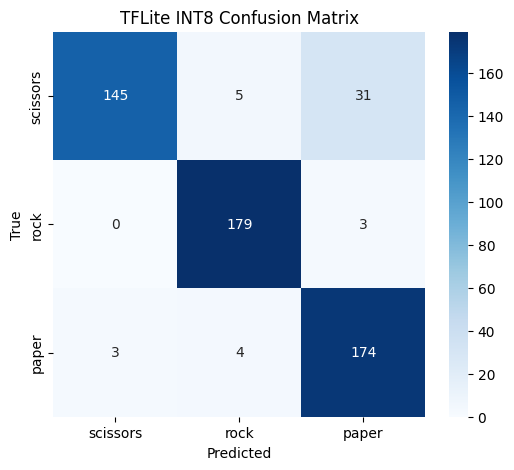

In [ ]:

# =========================================================
# 18. Confusion matrix for TFLite predictions
# =========================================================
cm = confusion_matrix(test_labels, tflite_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("TFLite INT8 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:

# =========================================================
# 19. Classification report
# =========================================================
print(
    classification_report(
        test_labels,
        tflite_predictions,
        target_names=CLASS_NAMES,
        digits=4,
    )
)


              precision    recall  f1-score   support

    scissors     0.9797    0.8011    0.8815       181
        rock     0.9521    0.9835    0.9676       182
       paper     0.8365    0.9613    0.8946       181

    accuracy                         0.9154       544
   macro avg     0.9228    0.9153    0.9145       544
weighted avg     0.9229    0.9154    0.9146       544



## 13. Accuracy vs Size Plot

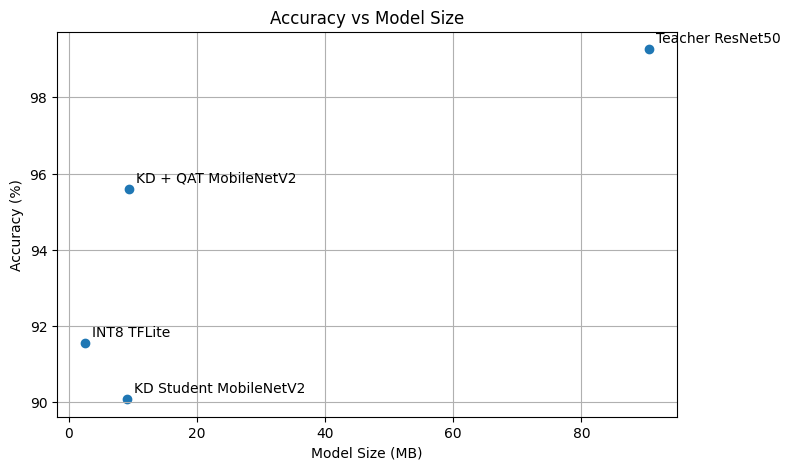

In [ ]:

# =========================================================
# 20. Accuracy vs model size
# =========================================================
plt.figure(figsize=(8, 5))
plt.scatter(model_summary["Size (MB)"], model_summary["Accuracy (%)"])

for _, row in model_summary.iterrows():
    plt.annotate(
        row["Model"],
        (row["Size (MB)"], row["Accuracy (%)"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Model Size")
plt.grid(True)
plt.show()


## 14. Download output files in Colab

In [ ]:

# =========================================================
# 21. Download generated files in Colab
# =========================================================
try:
    from google.colab import files

    for filename in [
        "teacher_resnet50.h5",
        "student_mobilenetv2_kd.h5",
        "student_mobilenetv2_kd_qat.h5",
        "RPS_MobileNetV2_KD_QAT_INT8.tflite",
    ]:
        if os.path.exists(filename):
            print("Downloading:", filename)
            files.download(filename)
        else:
            print("Missing:", filename)
except Exception as e:
    print("Not running in Colab or download failed:", e)


Downloading: teacher_resnet50.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: student_mobilenetv2_kd.h5


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: RPS_MobileNetV2_KD_QAT_INT8.tflite


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>